Train_test_split

In [2]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np


In [3]:
data = {
    "Study_Hours" : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Marks"       : [32, 38, 43, 50, 54, 61, 68, 73, 81, 88]
}

In [4]:
df = pd.DataFrame(data)
df

,Study_Hours,Marks
0,1,32
1,2,38
2,3,43
3,4,50
4,5,54
5,6,61
6,7,68
7,8,73
8,9,81
9,10,88


In [5]:
x = df[["Study_Hours"]]
y = df["Marks"]

In [6]:
x

,Study_Hours
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [7]:
y

0    32
1    38
2    43
3    50
4    54
5    61
6    68
7    73
8    81
9    88
Name: Marks, dtype: int64

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [9]:
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [10]:
print("Intercept : ", model.intercept_)
print("Slope : ", model.coef_[0])
print("Actual values : ", y_test.values)
print("Predicted values : ", y_pred)

Intercept :  24.724137931034484
Slope :  6.163793103448276
Actual values :  [81 38]
Predicted values :  [80.19827586 37.05172414]


In [11]:
print("MAE       : ", mean_absolute_error(y_test, y_pred))
print("MSE       : ", mean_squared_error(y_test, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared : ", r2_score(y_test, y_pred))

MAE       :  0.875
MSE       :  0.7709943519619504
RMSE      :  0.8780628405541089
R-squared :  0.9983320836085193


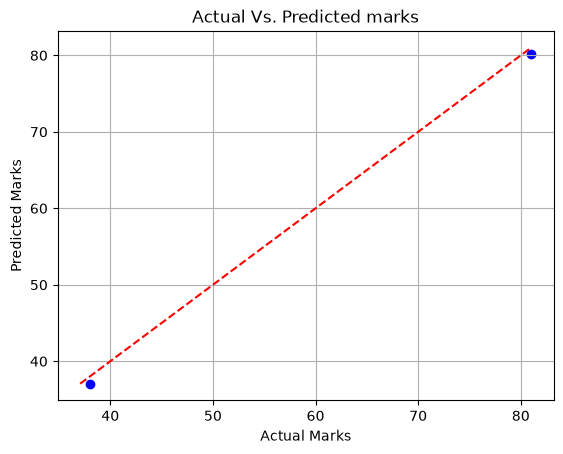

In [37]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color = "blue")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color = "red",
    linestyle = "--"
)


plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual Vs. Predicted marks")
plt.grid(True)
plt.show()

After Applying Ridge :

In [38]:
from sklearn.linear_model import RidgeCV, Ridge, LassoCV, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas = [0.01, 0.1, 1, 10, 100])
)

model.fit(x_train, y_train)

ridge_model = model.named_steps["ridgecv"]
print("Best alpha : ", ridge_model.alpha_)

Best alpha :  0.01


In [39]:
model = make_pipeline(
    StandardScaler(),
    Ridge(alpha = 0.01)
    )

model.fit(x_train, y_train)
y_pred = model.predict(x_test)
y_pred

array([80.17134293, 37.07865707])

In [40]:
ridge_step = model.named_steps['ridge']

print("Intercept : ", ridge_step.intercept_)
print("Standard coefficients : ", ridge_step.coef_)

Intercept :  58.625
Standard coefficients :  [16.5758011]


In [41]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print("MAE       : ", mean_absolute_error(y_test, y_pred))
print("MSE       : ", mean_squared_error(y_test, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared : ", r2_score(y_test, y_pred))

MAE       :  0.875
MSE       :  0.7677726674763221
RMSE      :  0.8762263791260351
R-squared :  0.9983390531801486


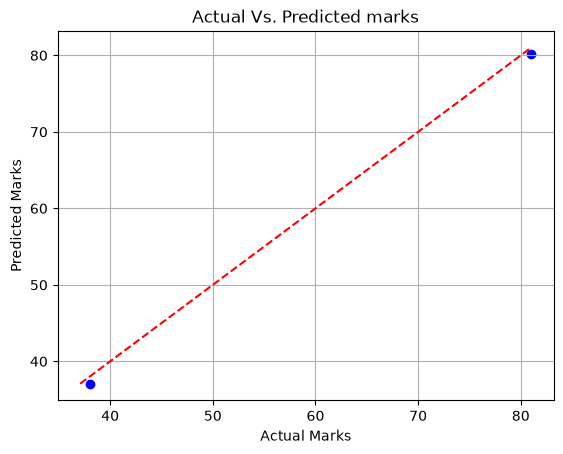

In [42]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color = "blue")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color = "red",
    linestyle = "--"
)


plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual Vs. Predicted marks")
plt.grid(True)
plt.show()

Lasso Applied

In [43]:
model = make_pipeline(
    StandardScaler(),
    LassoCV(alphas = [0.01, 0.1, 1, 10, 100])
)

model.fit(x_train, y_train)

ridge_model = model.named_steps["lassocv"]
print("Best alpha : ", ridge_model.alpha_)

Best alpha :  0.01


In [44]:
model = make_pipeline(
    StandardScaler(),
    Lasso(alpha = 0.01)
    )

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [45]:
lasso_step = model.named_steps['lasso']

print("Intercept : ", lasso_step.intercept_)
print("Standard coefficients : ", lasso_step.coef_)

Intercept :  58.625
Standard coefficients :  [16.58652085]


In [46]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print("MAE       : ", mean_absolute_error(y_test, y_pred))
print("MSE       : ", mean_squared_error(y_test, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared : ", r2_score(y_test, y_pred))

MAE       :  0.875
MSE       :  0.7692583394409954
RMSE      :  0.8770737366042809
R-squared :  0.9983358391791434


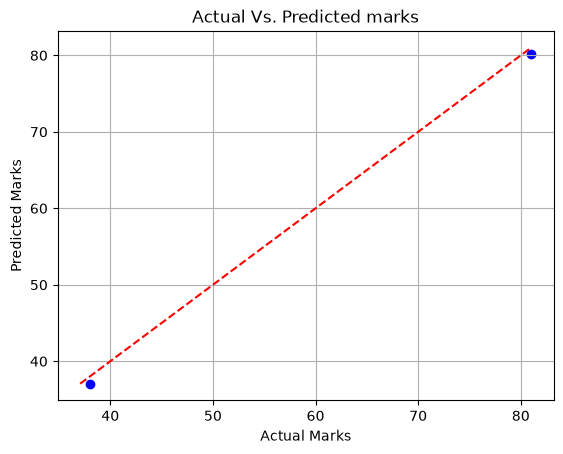

In [47]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color = "blue")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color = "red",
    linestyle = "--"
)


plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual Vs. Predicted marks")
plt.grid(True)
plt.show()